# Tree-based ML and Feature Selection

**This week, your assignment is:**

- use our prepared churn data from week 2
- break our data into features and targets, and train and test sets
- use sklearn to fit a decision tree to the training data
    - plot the decision tree
    - change the max_depth of the decision tree to improve the model if needed (or tune it with a hyperparameter search)
- plot the correlations between features and targets
- use sklearn to fit a random forest model to predict churn from our dataset
    - plot the feature importances from the random forest
- choose some of the less-important features to remove from the model using feature importances and correlations and fit the random forest model to the new data
    - examine the feature importances after removing less important features
- write a short analysis of the results of your work


***Optional* advanced tasks:**
- use H2O to fit a random forest to our original, unmodified data (missing values and all)
    - you can decide if you want to break the data into train and test sets or not, but remember it's best to evaluate performance on a test or validation dataset
    - plot the H2O random forest's feature importances
- tune the random forest hyperparameters for the sklearn and/or H2O models
- use forward and/or backward selection with feature importances from a random forest model
- use recursive feature selection
- compare the various feature selection methods you tried and write a short summary

In [39]:
'''
Importing our data.
We remove the normalized numeric data cause it's not needed for decision
trees.
Also, due to feedback from last week's assignment, we decided to remove
the monthly charges over median variable to avoid multicollinearity.
'''

import pandas as pd

df = pd.read_csv('churn_cleaned.csv')
df.drop('yj_tenure', axis=1, inplace=True)
df.drop('yj_monthly_charges', axis=1, inplace=True)
df.drop('yj_total_charges', axis=1, inplace=True)
df.drop('MonthlyCharges_over_Median', axis=1, inplace=True)
df.head()

,tenure,PhoneService,MonthlyCharges,TotalCharges,Churn,Month-to-month,One year,Two year,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
0,1,0,29.85,29.85,0,1,0,0,0,0,1,0
1,34,1,56.95,1889.50,0,0,1,0,0,0,0,1
2,2,1,53.85,108.15,1,1,0,0,0,0,0,1
3,45,0,42.30,1840.75,0,0,1,0,1,0,0,0
4,2,1,70.70,151.65,1,1,0,0,0,0,1,0


In [40]:
#Break our data into train and test sets + features and targets.
from sklearn.model_selection import train_test_split

features = df.drop('Churn', axis=1)
target = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(features, target, stratify=target, random_state=0)

In [41]:
'''
Now we will fit our sets to a decision tree model
We find that our test accuracy is extremely high and way too fitted.
This is because we are using a depth of 28!  We need to lower the amount 
of depth we use.
'''

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
dt.fit(x_train, y_train)
ts = dt.score(x_train, y_train)
ta = dt.score(x_test, y_test)
print('Training score: %.4f' % ts)
print('Test accuracy: %.4f' % ta)
print('Difference between training score and test accuracy: %.4f' % (ts-ta))
print('Tree depth: ', dt.get_depth())

Training score: 0.9943
Test accuracy: 0.7218
Difference between training score and test accuracy: 0.2725
Tree depth:  28


In [42]:
'''
Let's try reducing our depth maximum.
We can run through a couple depth to see what gives us the best
test accuracy.

Seems like a depth of 3 gives us the best test accuracy before
it levels off and starts to decreases.  Depth of 3 or 4 is usuable, 
but the depth of 3 has the better training score.
'''

for i in range(1, 8):
    dt = DecisionTreeClassifier(max_depth=i, random_state=0)
    dt.fit(x_train, y_train)
    ts = dt.score(x_train, y_train)
    ta = dt.score(x_test, y_test)
    print('Depth of ', i,)
    print('Training score: %.4f' %ts)
    print('Test accuracy: %.4f' %ta, '\n')

Depth of  1
Training score: 0.7342
Test accuracy: 0.7344 

Depth of  2
Training score: 0.7491
Test accuracy: 0.7554 

Depth of  3
Training score: 0.7873
Test accuracy: 0.7861 

Depth of  4
Training score: 0.7931
Test accuracy: 0.7861 

Depth of  5
Training score: 0.7941
Test accuracy: 0.7838 

Depth of  6
Training score: 0.8049
Test accuracy: 0.7827 

Depth of  7
Training score: 0.8148
Test accuracy: 0.7821 



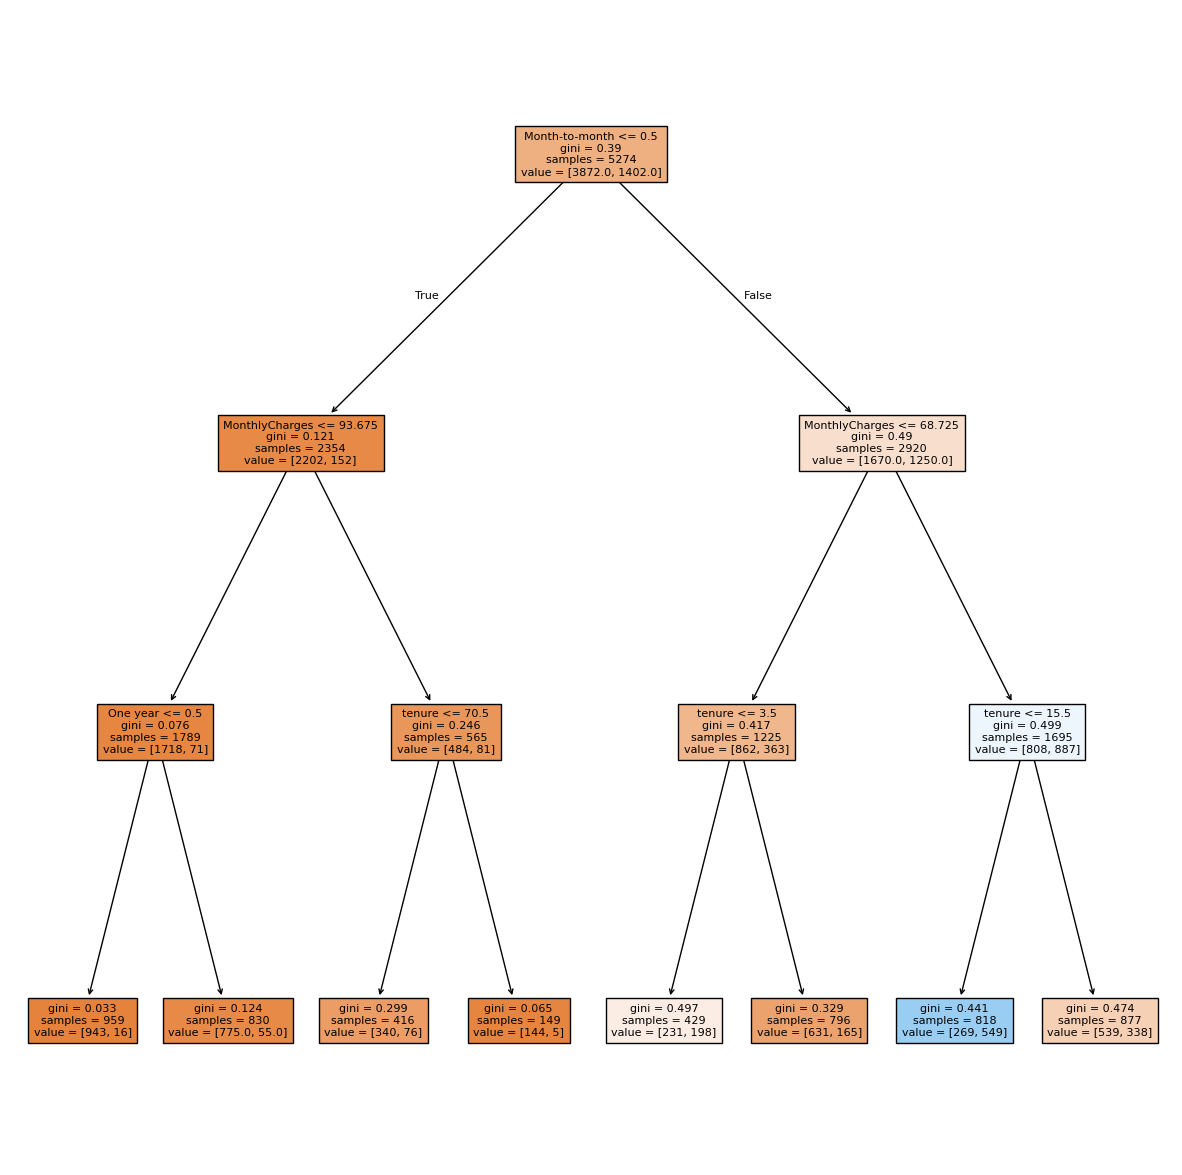

In [43]:
'''
Let's plot our decision tree
'''

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(x_train, y_train)

f = plt.figure(figsize=(15, 15))
_ = plot_tree(dt, fontsize=8, feature_names=features.columns, filled=True)

In [44]:
'''
Let's find the correlation between the target and the features
'''
importances = dt.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df)

                      Feature  Gini Importance
4              Month-to-month         0.638844
0                      tenure         0.204085
2              MonthlyCharges         0.153014
5                    One year         0.004057
1                PhoneService         0.000000
3                TotalCharges         0.000000
6                    Two year         0.000000
7   Bank transfer (automatic)         0.000000
8     Credit card (automatic)         0.000000
9            Electronic check         0.000000
10               Mailed check         0.000000


In [45]:
'''
We can see that many of our variables are not important.
Our decision tree only has three branches, so we can get rid of 
the variables it doesn't even use to split.
Let's remove some of our less important features
'''

new_features = features.drop(['Bank transfer (automatic)', 
                               'Credit card (automatic)', 'PhoneService',
                               'Mailed check', 'Electronic check', 
                              'Two year', 'TotalCharges',
                             'One year'], axis=1)

In [46]:
'''
We now fit our new features to a decision tree with a depth of 3.
Our test accuracy and training score remain exactly the same
'''

x_train, x_test, y_train, y_test = train_test_split(new_features, target,
                                                    stratify=target,
                                                    random_state=0)
dt.fit(x_train, y_train)
ts = dt.score(x_train, y_train)
ta = dt.score(x_test, y_test)
print('Training score: %.4f' %ts)
print('Test accuracy: %.4f' %ta)

Training score: 0.7873
Test accuracy: 0.7861


In [47]:
'''
If we take a look again at our feature importance, we see that
our features remaining went up a little with their scores.
'''

importances = dt.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': new_features.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df)

          Feature  Gini Importance
2  Month-to-month         0.639887
0          tenure         0.204418
1  MonthlyCharges         0.155695


In [48]:
'''
Now let's try fitting a Random Forest Model to our data
'''

from sklearn.ensemble import RandomForestClassifier

features = df.drop('Churn', axis=1)
target = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(features, target, stratify=target, random_state=0)
rfc = RandomForestClassifier(max_depth=4, random_state=0)

rfc.fit(x_test, y_test)
ts = rfc.score(x_train, y_train)
ta = rfc.score(x_test, y_test)

print('Training score: %.4f' %ts)
print('Test accuracy: %.4f' %ta)
print('Difference between training score and test accuracy: %.4f' %abs(ts-ta))

Training score: 0.7918
Test accuracy: 0.7975
Difference between training score and test accuracy: 0.0057


In [49]:
'''
Now we take a look at the feature importance for the random forest model.
'''

importances = rfc.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df)

                      Feature  Gini Importance
4              Month-to-month         0.271379
0                      tenure         0.180449
2              MonthlyCharges         0.166083
6                    Two year         0.133586
9            Electronic check         0.096732
3                TotalCharges         0.091254
5                    One year         0.029072
8     Credit card (automatic)         0.011190
10               Mailed check         0.010601
7   Bank transfer (automatic)         0.005718
1                PhoneService         0.003937


In [50]:
'''
Now we remove some of our less important features and fit a new 
random forest model to those features
We get different values for our training score and test accuracy,
but the difference is the same.
'''

new_features = features.drop(['Bank transfer (automatic)', 'PhoneService',
                              'Mailed check'], axis=1)
x_train, x_test, y_train, y_test = train_test_split(new_features, target, stratify=target, random_state=0)

rfc.fit(x_train, y_train)
ts = rfc.score(x_train, y_train)
ta = rfc.score(x_test, y_test)

print('Training score: %.4f' %ts)
print('Test accuracy: %.4f' %ta)
print('Difference between training score and test accuracy: %.4f' %abs(ts-ta))

Training score: 0.7893
Test accuracy: 0.7816
Difference between training score and test accuracy: 0.0078


In [51]:
#Feature importance for our new improved random forest model
importances = rfc.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': new_features.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df)

                   Feature  Gini Importance
3           Month-to-month         0.256443
0                   tenure         0.228756
1           MonthlyCharges         0.145710
7         Electronic check         0.135635
2             TotalCharges         0.104328
5                 Two year         0.093704
4                 One year         0.031116
6  Credit card (automatic)         0.004308


In [52]:
'''
We can try optimizing our hyperparameters for our random forest model
We find that the best max depth is 5 with all 13 of our features, along
with 62 estimators.  We get a training score that is slightly higher.
'''

from skopt import BayesSearchCV

opt = BayesSearchCV(
    RandomForestClassifier(),
    {
        'max_depth': (3, 10),
        'n_estimators': (50, 500),
        'max_features': (3, 13),
        'min_samples_split': (2, 5)
    },
    n_iter=32,
    cv=3,
    random_state = 0
)

opt.fit(x_train, y_train)
ts = round(opt.best_score_, 5)
ta = round(opt.score(x_test, y_test), 5)

print('Training score: ', ts)
print('Test accuracy: ', ta)
print(opt.best_params_)

Training score:  0.7975
Test accuracy:  0.7975
OrderedDict({'max_depth': 6, 'max_features': 13, 'min_samples_split': 5, 'n_estimators': 484})


In [53]:
'''
Let's fit an H20 model to our original, raw data
'''

#%conda install -c conda-forge h2o-py -y

import h2o

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,5 days 9 hours 5 mins
H2O_cluster_timezone:,America/Chicago
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,10 months and 20 days
H2O_cluster_name:,H2O_from_python_anaughton_5om2rt
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.148 Gb
H2O_cluster_total_cores:,10
H2O_cluster_allowed_cores:,10
H2O_cluster_status:,"locked, healthy"


In [54]:
hf = h2o.H2OFrame(pd.read_csv('churn_data.csv', index_col='customerID'))
hf

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,No,Month-to-month,Electronic check,29.85,29.85,No
34,Yes,One year,Mailed check,56.95,1889.5,No
2,Yes,Month-to-month,Mailed check,53.85,108.15,Yes
45,No,One year,Bank transfer (automatic),42.3,1840.75,No
2,Yes,Month-to-month,Electronic check,70.7,151.65,Yes
8,Yes,Month-to-month,Electronic check,99.65,820.5,Yes
22,Yes,Month-to-month,Credit card (automatic),89.1,1949.4,No
10,No,Month-to-month,Mailed check,29.75,301.9,No
28,Yes,Month-to-month,Electronic check,104.8,3046.05,Yes
62,Yes,One year,Bank transfer (automatic),56.15,3487.95,No


In [55]:
from h2o.estimators import H2ORandomForestEstimator

predictors = hf.columns
predictors.remove('Churn')
response = 'Churn'

# Split the dataset into a train and valid set:
train, valid = hf.split_frame(ratios=[.8], seed=1234, )

# Build and train the model:
drf = H2ORandomForestEstimator(ntrees=50,
                                    max_depth=4,
                                    calibrate_model=True,
                                    calibration_frame=valid)
drf.train(x=predictors,
           y=response,
           training_frame=train,
           validation_frame=valid)

# Eval performance:
perf = drf.model_performance(valid=valid)

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


In [56]:
perf

ModelMetricsBinomial: drf
** Reported on validation data. **

MSE: 0.13912711866416785
RMSE: 0.3729974780935762
LogLoss: 0.4254232646828334
Mean Per-Class Error: 0.23959222149085385
AUC: 0.8405413751351
AUCPR: 0.6479743247815127
Gini: 0.6810827502701999

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2955202356974284
       No    Yes    Error    Rate
-----  ----  -----  -------  --------------
No     751   266    0.2616   (266.0/1017.0)
Yes    79    284    0.2176   (79.0/363.0)
Total  830   550    0.25     (345.0/1380.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.29552      0.622125  184
max f2                       0.143521     0.750217  288
max f0point5                 0.405324     0.607705  125
max accuracy                 0.482329     0.793478  83
max precision                0.738714     1         0
max recall                   0.049762     1         371
max specificity              0.738714     1         0
max absolute_mcc             0.390688     0.475951  137
max min_per_class_accuracy   0.30354      0.748279  178
max mean_per_class_accuracy  0.281139     0.763565  195
max tns                      0.738714     1017      0
max fns                      0.738714     357       0
max fps                      0.0227927    1017      399
max tps                      0.049762     363       371
max tnr                      0.738714     1         0
max fnr                      0.738714     0.983471  0
max fpr                      0.0227927    1         399
max tpr                      0.049762     1         371

Gains/Lift Table: Avg response rate: 26.30 %, avg score: 26.79 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0101449                   0.732827           3.80165   3.80165            1                0.736249   1                           0.736249            0.0385675       0.0385675                  280.165   280.165            0.0385675
2        0.0231884                   0.73238            3.37925   3.56405            0.888889         0.732694   0.9375                      0.734249            0.0440771       0.0826446                  237.925   256.405            0.0806781
3        0.0304348                   0.678736           2.66116   3.34908            0.7              0.690899   0.880952                    0.723928            0.0192837       0.101928                   166.116   234.908            0.097012
4        0.0427536                   0.631489           2.90715   3.22174            0.764706         0.647401   0.847458                    0.701878            0.0358127       0.137741                   190.715   222.174            0.128891
5        0.05                        0.627621           3.42149   3.25069            0.9              0.629202   0.855072                    0.691345            0.0247934       0.162534                   242.149   225.069            0.152702
6        0.1                         0.597135           2.25895   2.75482            0.594203         0.613918   0.724638                    0.652632            0.112948        0.275482                   125.895   175.482            0.238117
7        0.150725                    0.523724           2.06375   2.52225            0.542857         0.560552   0.663462                    0.621643            0.104683        0.380165                   106.375   152.225            0.311335
8        0.202899      

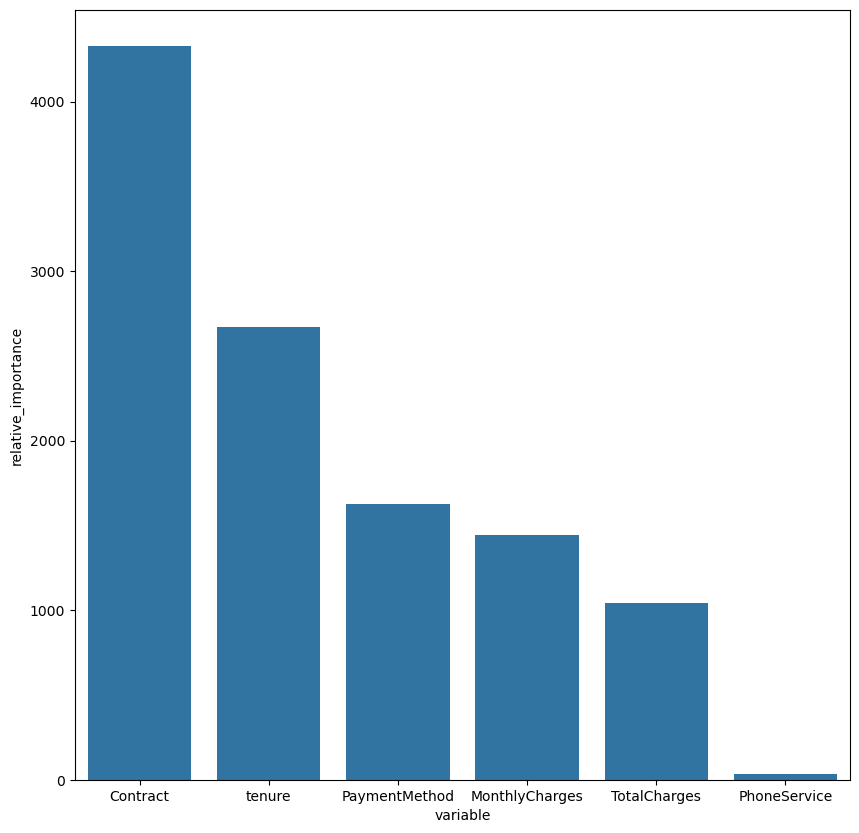

In [58]:
import seaborn as sns

variable_importance = drf.varimp(use_pandas=True)

#plot the variable importance
f = plt.figure(figsize=(10, 10))
_ = sns.barplot(x='variable', y='relative_importance', data=variable_importance)


# Summary

This week we try using decision trees and random forest for modeling our data.  The first decsion tree we tested was tuned to have a max depth of 3, returning a training score of 0.7873.  We then looked at the features that were most important in the decision tree and found that, after dropping some less useful features, that the contract type (specifidcally month-to-month payments) were the most important, followed by tenure and monthly charges over the median monthly charge (or just monthly charges in general), with a Gini Importance of 0.64, 0.2, and 0.16 respectively.

Next we fitted a random forest model to the same data and got a training score of .7763.  After removing some of the less important features, we see the training score improve slightly to 0.7867.  We find that once again, the contract type (month-to-month) and tenure are the two most important features, with Gini Importance of 0.27 and 0.22 respectively.  We also looked at optimizing our hyperparameters with a Bayes Search and ended up with a model that has a 0.7979 training score, the highest of all of our models.

Lastly we fitted an h20 model to our raw, uncleaned data.  We find that the three most important features are the contract type, tenure, and payment method.  It produced a max accuracy of 0.7963.

After analyzing some more models, along with out findings from last week, we are seeing that the contract type and the monthly charges seem to be the things that are most important in predicting if someone will churn or not.  It is interesting to see a combination of both a categorical variable and a numeric variaiable being the most important in our models.  

If we wanted to find a way to apply this to the buisness side of things, we might consider trying to get more people to sign contracts that aren't month-to-month.  We might also consider trying to find a breaking point for monthly charges so that we can see at what monthly charge do people overwhelmingly start to churn.